In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [86]:
num_thetas = 128
thetas = np.linspace(0, 2*np.pi, num_thetas, endpoint=False)
lambda_0 = 0.1
#lambda_theta =  np.zeros_like(thetas)
#lambda_theta[num_thetas//2] = lambda_0
#lambda_theta[num_thetas//4] = lambda_0
#lambda_theta[num_thetas//8] = lambda_0
lambda_theta = lambda_0 * (1 + 0.5 * np.cos(thetas - np.pi/4))
total_lambda = lambda_theta.sum()
f_theta = np.zeros_like(thetas)
x = 0.0
y = 0.0
phi = 0.0
D_phi = 0.1
D_r = 0.01
tau = 1.0
a = 0.1
dt = 0.01
simulation_time = 10000
time = 0
history = []
history_f_theta = []
while time < simulation_time:
    next_event_waiting_time = np.random.exponential(1/total_lambda)
    next_event_index = np.random.choice(num_thetas, p=lambda_theta/total_lambda)
    for step in range(int(next_event_waiting_time / dt)):
        force_x = (f_theta * np.cos(thetas - phi)).sum()
        force_y = (f_theta * np.sin(thetas - phi)).sum()
        x += force_x * dt + np.sqrt(2*D_r*dt) * np.random.randn()
        y += force_y * dt + np.sqrt(2*D_r*dt) * np.random.randn()
        phi += np.sqrt(2*D_phi*dt) * np.random.randn()
        f_theta -= f_theta * dt / tau
        time += dt
    f_theta[next_event_index] += a
    history.append((time, x, y, phi))
    history_f_theta.append(f_theta.copy())
history = np.array(history)
history_f_theta = np.array(history_f_theta)

In [87]:
dir_x = (history_f_theta*np.cos(thetas)).sum(axis=1)/history_f_theta.sum(axis=1)
dir_y = (history_f_theta*np.sin(thetas)).sum(axis=1)/history_f_theta.sum(axis=1)

In [88]:
msd = (history[:,1]**2 + history[:,2]**2)

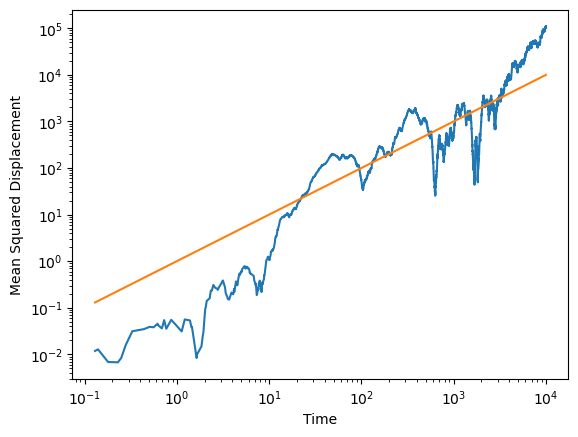

In [94]:
plt.plot(history[:,0], msd)
plt.plot(history[:,0], history[:,0])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Mean Squared Displacement')
plt.show()

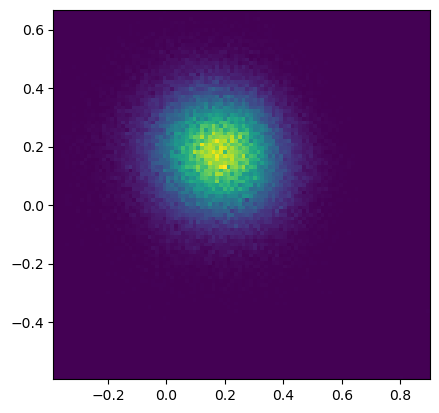

In [76]:
plt.hist2d(dir_x, dir_y, bins=100, cmap='viridis')
plt.gca().set_aspect('equal')
plt.show()

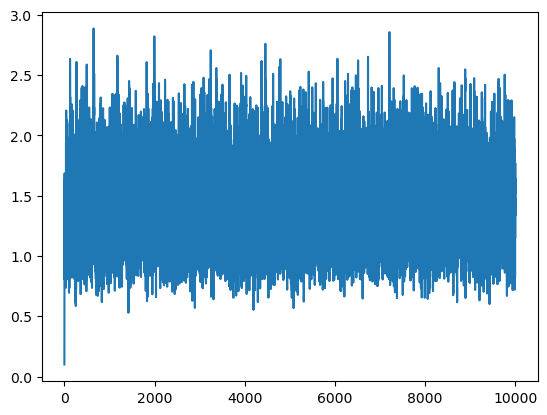

In [77]:
plt.plot(history[:,0], history_f_theta.sum(axis=1))

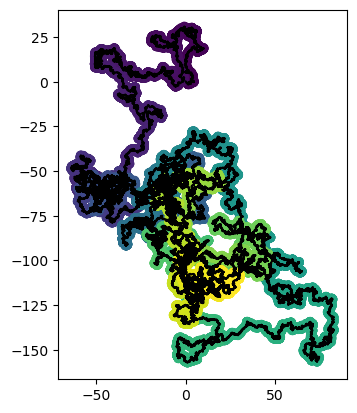

In [78]:
plt.plot(history[:,1], history[:,2], color='black')
plt.scatter(history[:,1], history[:,2], c=history[:,0], cmap='viridis')
plt.gca().set_aspect('equal')
plt.show()